## import packages

In [1]:
import numpy as np
import pandas as pd
from typing import Optional, Tuple
import sys

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time
from tqdm import tqdm

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

device = torch.device("cuda:0")


import shutil
import warnings
import pickle

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

from nn_functions import surrogate
from moving_average import moving_average_1d
import copy
from GAMMA_obj_temp_depth import GAMMA_obj

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss, TiDE_forward

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN


cuda is available


## define funcitons

In [2]:
# values from user
x_min = torch.tensor([[0.0, 0.75, 0.75, 504.26]], dtype=torch.float32).to(device)
x_max = torch.tensor([[7.5, 20.0, 20.0, 732.298]], dtype=torch.float32).to(device)

y_min = torch.tensor([[436.608, -0.559]], dtype=torch.float32).to(device)
y_max = torch.tensor([[4509.855, 0.551]], dtype=torch.float32).to(device)


In [3]:
def normalize_x(x, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 2 * (x - x_min_selected) / (x_max_selected - x_min_selected) - 1

def inverse_normalize_x(x_norm, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 0.5 * (x_norm + 1) * (x_max_selected - x_min_selected) + x_min_selected

def normalize_y(y, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 2 * (y - y_min_selected) / (y_max_selected - y_min_selected) - 1

def inverse_normalize_y(y_norm, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 0.5 * (y_norm + 1) * (y_max_selected - y_min_selected) + y_min_selected


In [4]:
import copy
import torch

def run_one_step_policy(
    GAMMA_obj,
    policy_model,
    P,
    window,
    mc_samples=50
):
    # =========================================================
    # 1. Reference trajectory
    # =========================================================
    mp_temp_ref = GAMMA_obj.ref[
        GAMMA_obj.MPC_counter : GAMMA_obj.MPC_counter + P
    ]
    mp_temp_ref_t = torch.as_tensor(
        mp_temp_ref, dtype=torch.float32, device=device
    ).reshape(1, P, 1)

    # =========================================================
    # 2. Past inputs
    # =========================================================
    mp_temp_past_t = GAMMA_obj.x_past.T.unsqueeze(0).to(device)
    laser_past_t   = GAMMA_obj.u_past.view(1, -1, 1).to(device)

    fix_cov_past = GAMMA_obj.fix_cov_all[
        GAMMA_obj.MPC_counter - window : GAMMA_obj.MPC_counter, :
    ]
    fix_cov_past_t = torch.as_tensor(
        fix_cov_past, dtype=torch.float32, device=device
    ).unsqueeze(0)

    # =========================================================
    # 3. Normalize
    # =========================================================
    fix_cov_past_s = normalize_x(fix_cov_past_t, dim_id=[0, 1, 2])
    laser_past_s   = normalize_x(laser_past_t,   dim_id=[3])
    mp_temp_past_s = normalize_y(mp_temp_past_t, dim_id=[0, 1])

    policy_in_past = torch.cat(
        (fix_cov_past_s, laser_past_s, mp_temp_past_s), dim=2
    )

    # =========================================================
    # 4. Future inputs
    # =========================================================
    fix_cov_future = GAMMA_obj.fix_cov_all[
        GAMMA_obj.MPC_counter : GAMMA_obj.MPC_counter + P, :
    ]
    fix_cov_future_t = torch.as_tensor(
        fix_cov_future, dtype=torch.float32, device=device
    ).unsqueeze(0)

    fix_cov_future_s = normalize_x(fix_cov_future_t, dim_id=[0, 1, 2])
    mp_temp_ref_s = normalize_y(mp_temp_ref_t, dim_id=[0])[:, :, 0].unsqueeze(-1)

    y_const_s = torch.tensor(
        [[0.1423, 0.4126]] * P,
        dtype=torch.float32,
        device=device
    ).reshape(1, P, 2)

    policy_in_future = torch.cat(
        (fix_cov_future_s, mp_temp_ref_s, y_const_s), dim=2
    )

    # =========================================================
    # 5. MC Dropout → u 분포 추정
    # =========================================================
    u_samples_s = []

    with torch.no_grad():
        for _ in range(mc_samples):
            u_pred = policy_model((policy_in_past, policy_in_future))
            u_samples_s.append(u_pred[0, 0, 0])

    u_samples_s = torch.stack(u_samples_s)  # [mc_samples]

    u_low_s  = torch.quantile(u_samples_s, 0.025)
    u_mid_s  = torch.quantile(u_samples_s, 0.5)
    u_high_s = torch.quantile(u_samples_s, 0.975)

    u_low  = float(inverse_normalize_x(u_low_s,  dim_id=[3]))
    u_mid  = float(inverse_normalize_x(u_mid_s,  dim_id=[3]))
    u_high = float(inverse_normalize_x(u_high_s, dim_id=[3]))

    # =======================
    # ### DEBUG PRINT ###
    # =======================
    if GAMMA_obj.MPC_counter % 100 == 0:   # 너무 많이 찍히는 거 방지
        u_s_np = u_samples_s.detach().cpu().numpy()
        print(
            f"[CI DEBUG @ step {GAMMA_obj.MPC_counter}] "
            f"u_low={u_low:.6f}, u_mid={u_mid:.6f}, u_high={u_high:.6f}, "
            f"spread={u_high - u_low:.6e}, "
            f"std(norm)={u_s_np.std():.6e}"
        )

    # =========================================================
    # 6. u_low / u_mid / u_high 로 상태 전파
    # =========================================================
    g_low  = copy.deepcopy(GAMMA_obj)
    g_mid  = copy.deepcopy(GAMMA_obj)
    g_high = copy.deepcopy(GAMMA_obj)

    x_low,  d_low  = g_low.run_sim_interval(u_low)
    x_mid,  d_mid  = g_mid.run_sim_interval(u_mid)
    x_high, d_high = g_high.run_sim_interval(u_high)

    # =========================================================
    # 7. 실제 시스템은 중앙값만
    # =========================================================
    x_current, depth_current = GAMMA_obj.run_sim_interval(u_mid)

    # =========================================================
    # 8. Past update
    # =========================================================
    GAMMA_obj.x_past[:, :-1] = GAMMA_obj.x_past[:, 1:]
    GAMMA_obj.x_past[0, -1] = x_current
    GAMMA_obj.x_past[1, -1] = depth_current

    GAMMA_obj.u_past[:-1] = GAMMA_obj.u_past[1:].clone()
    GAMMA_obj.u_past[-1] = u_mid

    GAMMA_obj.x_hat_current = torch.tensor(
        [x_current, depth_current], device=device
    )
    GAMMA_obj.x_sys_current = torch.tensor(
        [[x_current], [depth_current]], device=device
    )
    GAMMA_obj.MPC_counter += 1

    # =========================================================
    # 9. Save
    # =========================================================
    new_state = torch.tensor(
        [[x_current, depth_current]],
        device=GAMMA_obj.x_past_save.device
    )
    GAMMA_obj.x_past_save = torch.cat(
        (GAMMA_obj.x_past_save, new_state), dim=0
    )

    new_u = torch.tensor(
        [[u_mid]],
        device=GAMMA_obj.u_past_save.device
    )
    GAMMA_obj.u_past_save = torch.cat(
        (GAMMA_obj.u_past_save, new_u), dim=0
    )

    # =========================================================
    # 10. Return CI
    # =========================================================
    return {
        "u_low": u_low,
        "u_mid": u_mid,
        "u_high": u_high,
        "x_low": x_low,
        "x_mid": x_mid,
        "x_high": x_high,
        "d_low": d_low,
        "d_mid": d_mid,
        "d_high": d_high,
    }


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fig(MPC_GAMMA, window=50, save_path=None):
    # ===============================
    # lengths
    # ===============================
    T_x = MPC_GAMMA.x_past_save.shape[0]
    t_x = np.arange(T_x)

    # ===============================
    # trajectories (median)
    # ===============================
    x_mid = MPC_GAMMA.x_past_save.detach().cpu().numpy()
    temp_mid  = x_mid[:, 0]
    depth_mid = x_mid[:, 1]

    u_mid = MPC_GAMMA.u_past_save.detach().cpu().numpy().squeeze()

    ref = MPC_GAMMA.ref[:T_x].detach().cpu().numpy()

    # ===============================
    # CI (if exists)
    # ===============================
    has_x_ci = hasattr(MPC_GAMMA, "x_ci_save") and MPC_GAMMA.x_ci_save.shape[0] > 0
    has_u_ci = hasattr(MPC_GAMMA, "u_ci_save") and MPC_GAMMA.u_ci_save.shape[0] > 0

    if has_x_ci:
        x_ci = MPC_GAMMA.x_ci_save.detach().cpu().numpy()
        T_ci = x_ci.shape[0]
        t_ci = np.arange(T_x - T_ci, T_x)

    if has_u_ci:
        u_ci = MPC_GAMMA.u_ci_save.detach().cpu().numpy()
        T_ci_u = u_ci.shape[0]
        t_ci_u = np.arange(T_x - T_ci_u, T_x)

    # ===============================
    # plotting
    # ===============================
    plt.figure(figsize=(9, 7))

    # -------- Temperature --------
    plt.subplot(3, 1, 1)
    plt.plot(t_x, temp_mid, label="GAMMA simulation (median)")
    plt.plot(t_x, ref, "--", label="Reference")

    if has_x_ci:
        plt.fill_between(
            t_ci,
            x_ci[:, 0],   # temp_low
            x_ci[:, 2],   # temp_high
            alpha=0.3,
            color="tab:blue",
            label="95% CI"
        )

    plt.ylabel("Melt Pool Temperature (K)")
    plt.legend()

    # -------- Depth --------
    plt.subplot(3, 1, 2)
    plt.plot(t_x, depth_mid, label="GAMMA simulation (median)")
    plt.plot(t_x, 0.225 * np.ones(T_x), "--", label="Upper Bound")
    plt.plot(t_x, 0.075 * np.ones(T_x), "--", label="Lower Bound")

    if has_x_ci:
        plt.fill_between(
            t_ci,
            x_ci[:, 3],   # depth_low
            x_ci[:, 5],   # depth_high
            alpha=0.3,
            color="tab:blue",
            label="95% CI"
        )

    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend()

    # -------- Laser Power --------
    plt.subplot(3, 1, 3)
    plt.plot(t_x, u_mid, label="Laser Power (median)")

    if has_u_ci:
        plt.fill_between(
            t_ci_u,
            u_ci[:, 0],   # u_low
            u_ci[:, 2],   # u_high
            alpha=0.3,
            color="tab:orange",
            label="95% CI"
        )

    plt.ylabel("Laser Power (W)")
    plt.xlabel("MPC time step")
    plt.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        plt.close()
        print(f"Saved plot to {save_path}")
    else:
        plt.show()


## run loop

Laser 2:   0%|          | 0/6195 [00:00<?, ?it/s]

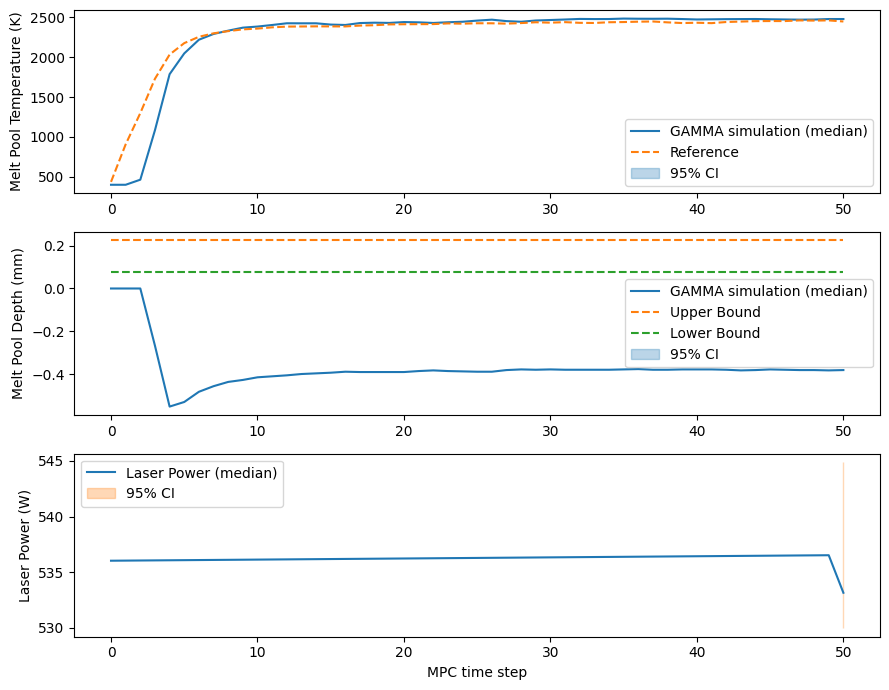

Laser 2:   1%|          | 50/6195 [00:33<1:08:26,  1.50it/s]

[CI DEBUG @ step 100] u_low=539.342285, u_mid=541.887878, u_high=552.419495, spread=1.307721e+01, std(norm)=3.160023e-02


Laser 2:   2%|▏         | 150/6195 [01:41<1:07:53,  1.48it/s]

[CI DEBUG @ step 200] u_low=553.132690, u_mid=556.330261, u_high=565.121460, spread=1.198877e+01, std(norm)=3.065453e-02


Laser 2:   4%|▍         | 250/6195 [02:49<1:08:38,  1.44it/s]

[CI DEBUG @ step 300] u_low=561.467163, u_mid=564.477966, u_high=571.983887, spread=1.051672e+01, std(norm)=2.529184e-02


Laser 2:   5%|▍         | 300/6195 [03:24<1:07:10,  1.46it/s]

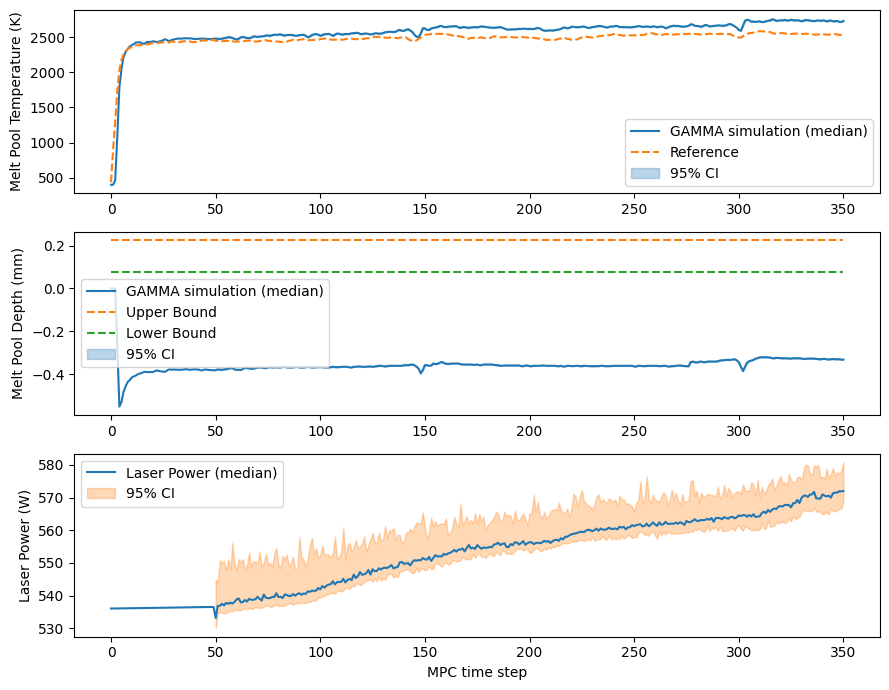

Laser 2:   6%|▌         | 350/6195 [04:00<1:10:07,  1.39it/s]

[CI DEBUG @ step 400] u_low=580.866882, u_mid=586.194702, u_high=593.473022, spread=1.260614e+01, std(norm)=2.767009e-02


Laser 2:   7%|▋         | 450/6195 [05:13<1:11:03,  1.35it/s]

[CI DEBUG @ step 500] u_low=601.322449, u_mid=603.073730, u_high=608.209229, spread=6.886780e+00, std(norm)=1.804961e-02


Laser 2:   9%|▉         | 550/6195 [06:18<50:07,  1.88it/s]  

[CI DEBUG @ step 600] u_low=614.760498, u_mid=625.549500, u_high=634.593750, spread=1.983325e+01, std(norm)=3.680200e-02


Laser 2:  10%|▉         | 600/6195 [06:45<50:09,  1.86it/s]

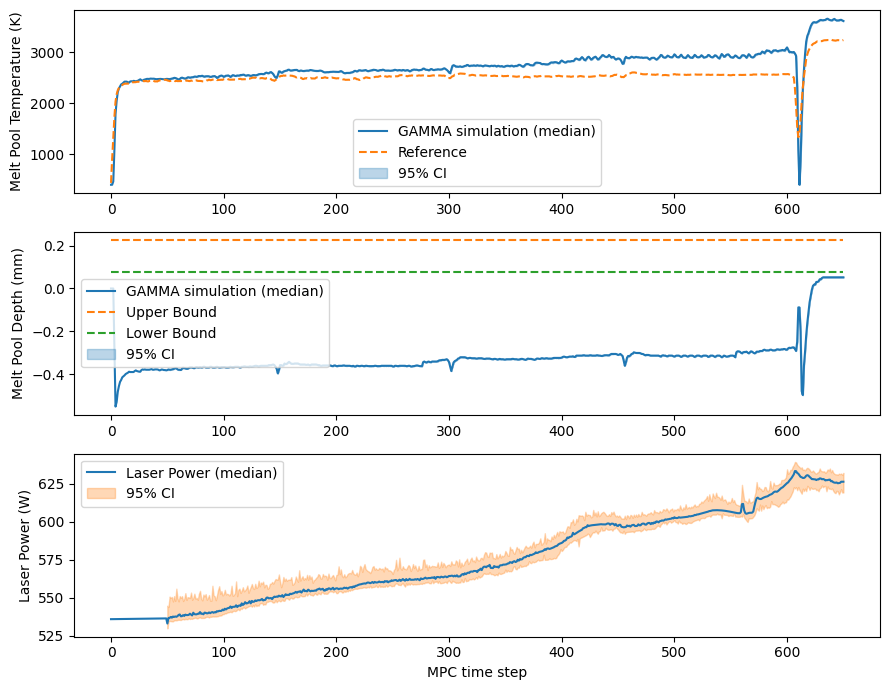

Laser 2:  10%|█         | 650/6195 [07:12<49:24,  1.87it/s]

[CI DEBUG @ step 700] u_low=610.433960, u_mid=618.994934, u_high=625.025391, spread=1.459143e+01, std(norm)=3.157681e-02


Laser 2:  12%|█▏        | 750/6195 [08:06<50:04,  1.81it/s]

[CI DEBUG @ step 800] u_low=599.149414, u_mid=602.085632, u_high=606.814392, spread=7.664978e+00, std(norm)=1.699442e-02


Laser 2:  14%|█▎        | 850/6195 [09:00<48:13,  1.85it/s]

[CI DEBUG @ step 900] u_low=596.898132, u_mid=602.263367, u_high=608.043457, spread=1.114532e+01, std(norm)=2.463379e-02


Laser 2:  15%|█▍        | 900/6195 [09:27<47:42,  1.85it/s]

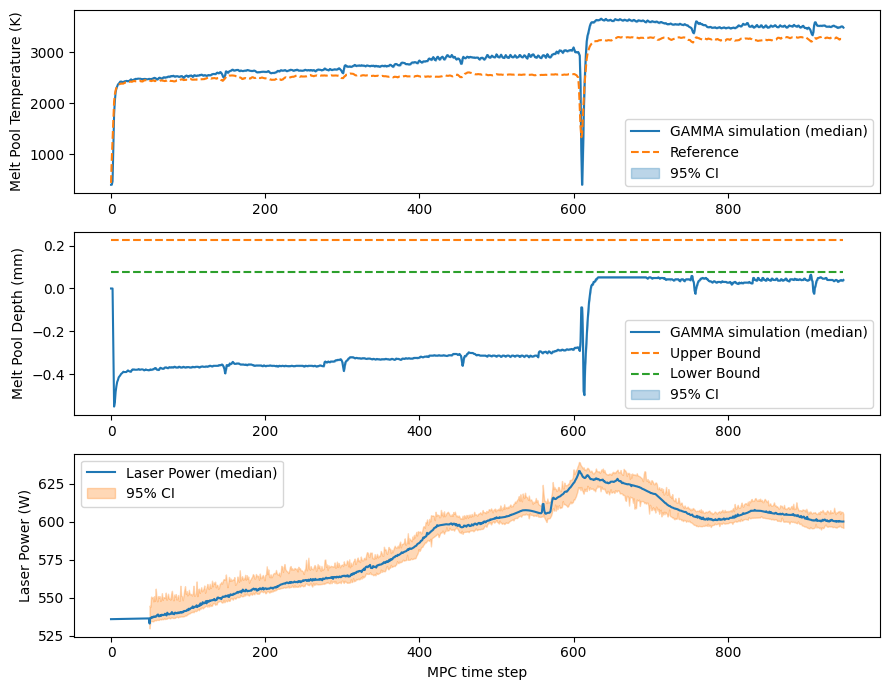

Laser 2:  15%|█▌        | 950/6195 [09:54<48:21,  1.81it/s]

[CI DEBUG @ step 1000] u_low=597.801270, u_mid=603.515747, u_high=612.279968, spread=1.447870e+01, std(norm)=2.690973e-02


Laser 2:  17%|█▋        | 1050/6195 [10:48<46:08,  1.86it/s]

[CI DEBUG @ step 1100] u_low=595.194702, u_mid=597.629395, u_high=602.817932, spread=7.623230e+00, std(norm)=1.752865e-02


Laser 2:  19%|█▊        | 1150/6195 [11:43<46:19,  1.81it/s]

[CI DEBUG @ step 1200] u_low=605.888916, u_mid=617.859619, u_high=622.296692, spread=1.640778e+01, std(norm)=3.131033e-02


Laser 2:  19%|█▉        | 1200/6195 [12:10<46:10,  1.80it/s]

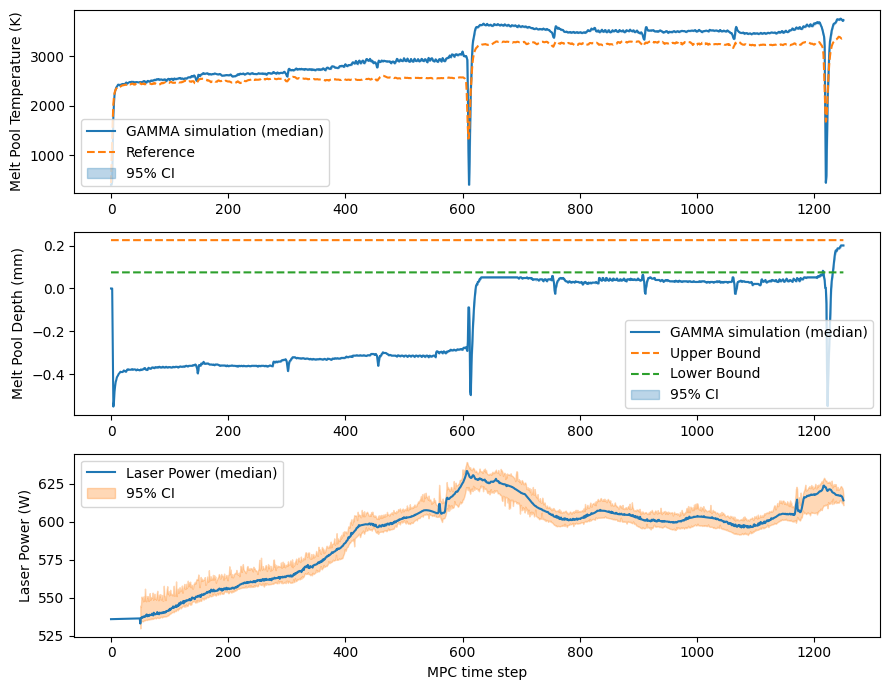

Laser 2:  20%|██        | 1250/6195 [12:39<47:57,  1.72it/s]

[CI DEBUG @ step 1300] u_low=604.734375, u_mid=613.343140, u_high=616.318359, spread=1.158398e+01, std(norm)=2.759998e-02


Laser 2:  22%|██▏       | 1350/6195 [13:35<46:01,  1.75it/s]

[CI DEBUG @ step 1400] u_low=593.516235, u_mid=595.902588, u_high=601.592896, spread=8.076660e+00, std(norm)=1.684831e-02


Laser 2:  23%|██▎       | 1450/6195 [14:32<44:07,  1.79it/s]

[CI DEBUG @ step 1500] u_low=579.571899, u_mid=582.162354, u_high=586.745605, spread=7.173706e+00, std(norm)=1.534319e-02


Laser 2:  24%|██▍       | 1500/6195 [15:00<43:57,  1.78it/s]

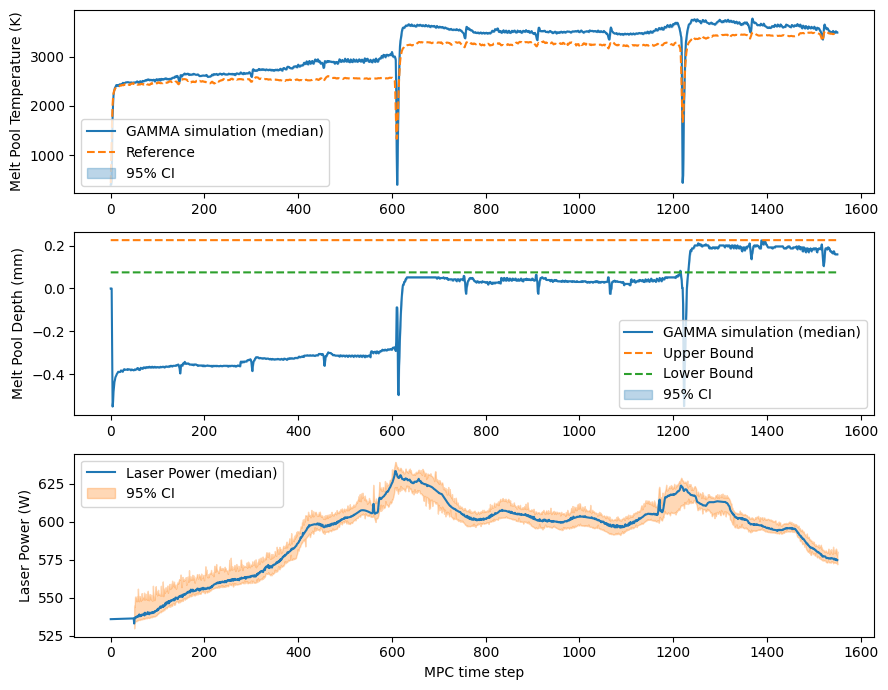

Laser 2:  25%|██▌       | 1550/6195 [15:28<44:20,  1.75it/s]

[CI DEBUG @ step 1600] u_low=578.538696, u_mid=580.421814, u_high=583.831360, spread=5.292664e+00, std(norm)=1.305362e-02


Laser 2:  27%|██▋       | 1650/6195 [16:24<42:39,  1.78it/s]

[CI DEBUG @ step 1700] u_low=575.938599, u_mid=578.531250, u_high=583.591614, spread=7.653015e+00, std(norm)=2.026265e-02


Laser 2:  28%|██▊       | 1750/6195 [17:21<41:41,  1.78it/s]

[CI DEBUG @ step 1800] u_low=577.122192, u_mid=579.619019, u_high=583.909607, spread=6.787415e+00, std(norm)=1.599864e-02


Laser 2:  29%|██▉       | 1800/6195 [17:50<43:42,  1.68it/s]

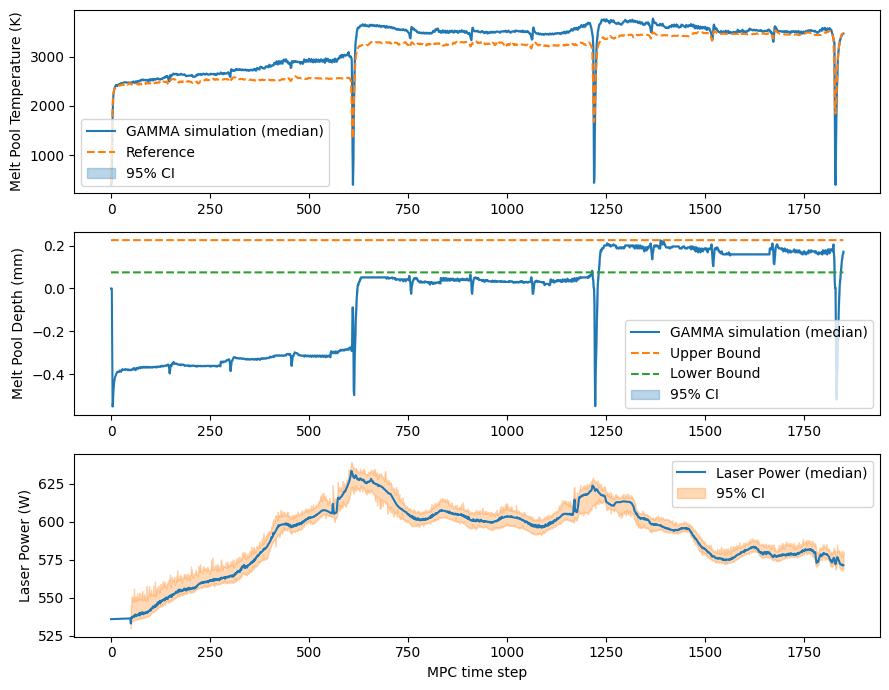

Laser 2:  30%|██▉       | 1850/6195 [18:19<41:16,  1.75it/s]

[CI DEBUG @ step 1900] u_low=574.562927, u_mid=575.846252, u_high=580.651855, spread=6.088928e+00, std(norm)=1.634557e-02


Laser 2:  31%|███▏      | 1950/6195 [19:16<41:06,  1.72it/s]

[CI DEBUG @ step 2000] u_low=541.480347, u_mid=545.018982, u_high=551.272339, spread=9.791992e+00, std(norm)=2.543626e-02


Laser 2:  33%|███▎      | 2050/6195 [20:13<38:55,  1.78it/s]

[CI DEBUG @ step 2100] u_low=526.545898, u_mid=530.527222, u_high=543.178772, spread=1.663287e+01, std(norm)=4.500030e-02


Laser 2:  34%|███▍      | 2100/6195 [20:41<38:40,  1.76it/s]

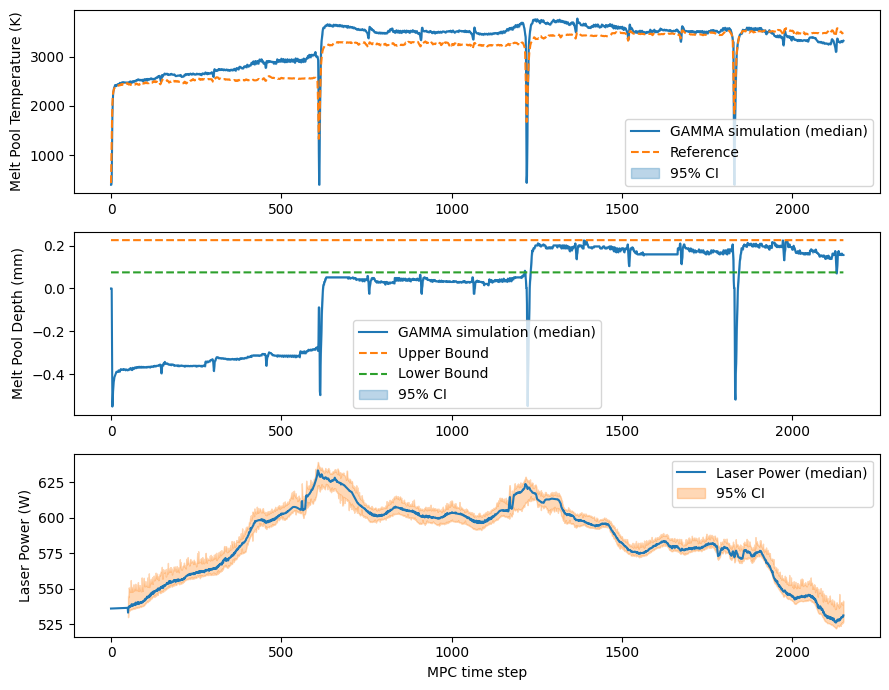

Laser 2:  35%|███▍      | 2150/6195 [21:10<38:36,  1.75it/s]

[CI DEBUG @ step 2200] u_low=526.436646, u_mid=530.239075, u_high=541.169434, spread=1.473279e+01, std(norm)=3.506569e-02


Laser 2:  36%|███▋      | 2250/6195 [22:07<37:51,  1.74it/s]

[CI DEBUG @ step 2300] u_low=501.337067, u_mid=507.022217, u_high=523.612427, spread=2.227536e+01, std(norm)=5.012517e-02


Laser 2:  38%|███▊      | 2350/6195 [23:06<38:12,  1.68it/s]

[CI DEBUG @ step 2400] u_low=489.465668, u_mid=494.173950, u_high=507.005066, spread=1.753940e+01, std(norm)=4.631413e-02


Laser 2:  39%|███▊      | 2400/6195 [23:35<36:29,  1.73it/s]

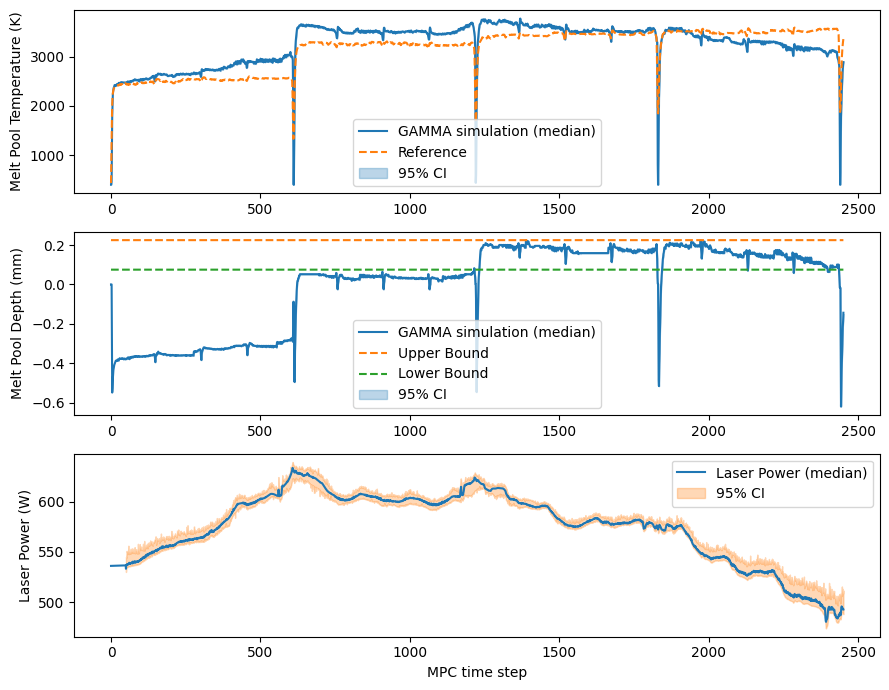

Laser 2:  40%|███▉      | 2450/6195 [24:04<36:15,  1.72it/s]

[CI DEBUG @ step 2500] u_low=472.107330, u_mid=477.865417, u_high=501.661285, spread=2.955396e+01, std(norm)=7.091206e-02


Laser 2:  41%|████      | 2550/6195 [25:03<36:47,  1.65it/s]

[CI DEBUG @ step 2600] u_low=450.624908, u_mid=459.696136, u_high=485.276001, spread=3.465109e+01, std(norm)=8.899678e-02


Laser 2:  43%|████▎     | 2650/6195 [26:02<34:36,  1.71it/s]

[CI DEBUG @ step 2700] u_low=432.119080, u_mid=440.398621, u_high=463.802185, spread=3.168311e+01, std(norm)=8.172440e-02


Laser 2:  44%|████▎     | 2700/6195 [26:31<34:52,  1.67it/s]

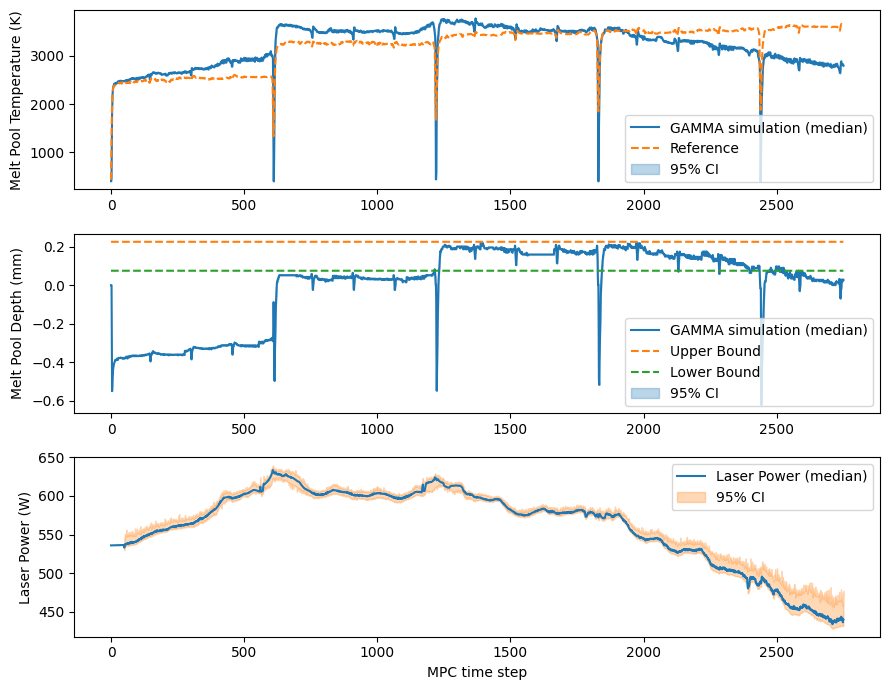

Laser 2:  44%|████▍     | 2750/6195 [27:01<34:30,  1.66it/s]

[CI DEBUG @ step 2800] u_low=418.081940, u_mid=426.654419, u_high=460.864868, spread=4.278293e+01, std(norm)=1.026593e-01


Laser 2:  46%|████▌     | 2850/6195 [28:01<33:54,  1.64it/s]

[CI DEBUG @ step 2900] u_low=413.749939, u_mid=421.666626, u_high=482.419983, spread=6.867004e+01, std(norm)=1.434487e-01


Laser 2:  48%|████▊     | 2950/6195 [29:00<31:58,  1.69it/s]

[CI DEBUG @ step 3000] u_low=398.572357, u_mid=405.569580, u_high=436.891174, spread=3.831882e+01, std(norm)=9.987333e-02


Laser 2:  48%|████▊     | 3000/6195 [29:29<29:18,  1.82it/s]

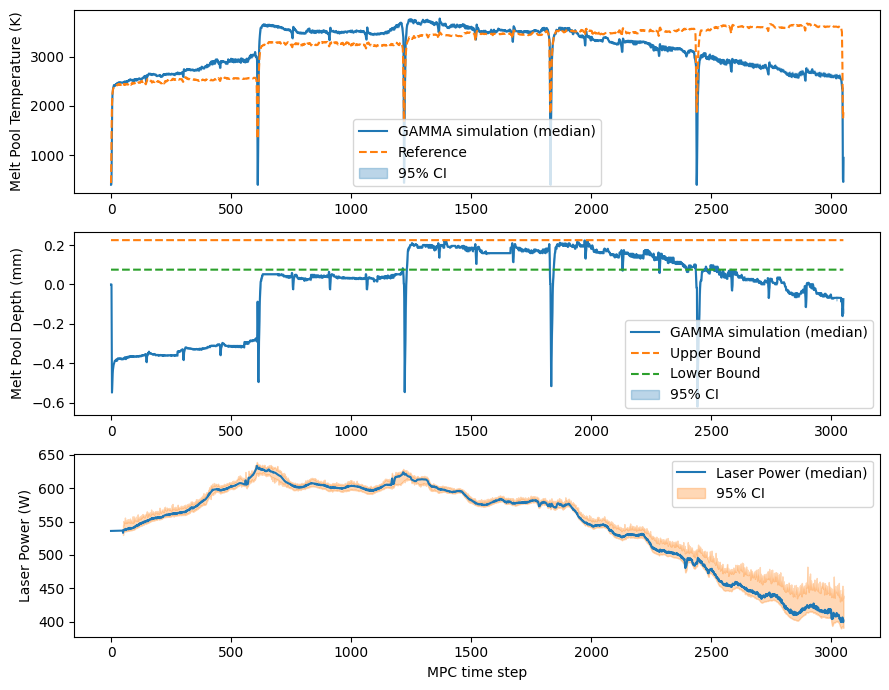

Laser 2:  49%|████▉     | 3050/6195 [29:59<30:48,  1.70it/s]

[CI DEBUG @ step 3100] u_low=379.188171, u_mid=389.034637, u_high=430.793030, spread=5.160486e+01, std(norm)=1.321103e-01


Laser 2:  51%|█████     | 3150/6195 [30:58<30:44,  1.65it/s]

[CI DEBUG @ step 3200] u_low=391.740234, u_mid=401.682953, u_high=436.346527, spread=4.460629e+01, std(norm)=1.126117e-01


Laser 2:  52%|█████▏    | 3250/6195 [31:56<28:51,  1.70it/s]

[CI DEBUG @ step 3300] u_low=352.042999, u_mid=364.895721, u_high=419.692505, spread=6.764951e+01, std(norm)=1.764387e-01


Laser 2:  53%|█████▎    | 3300/6195 [32:26<28:38,  1.68it/s]

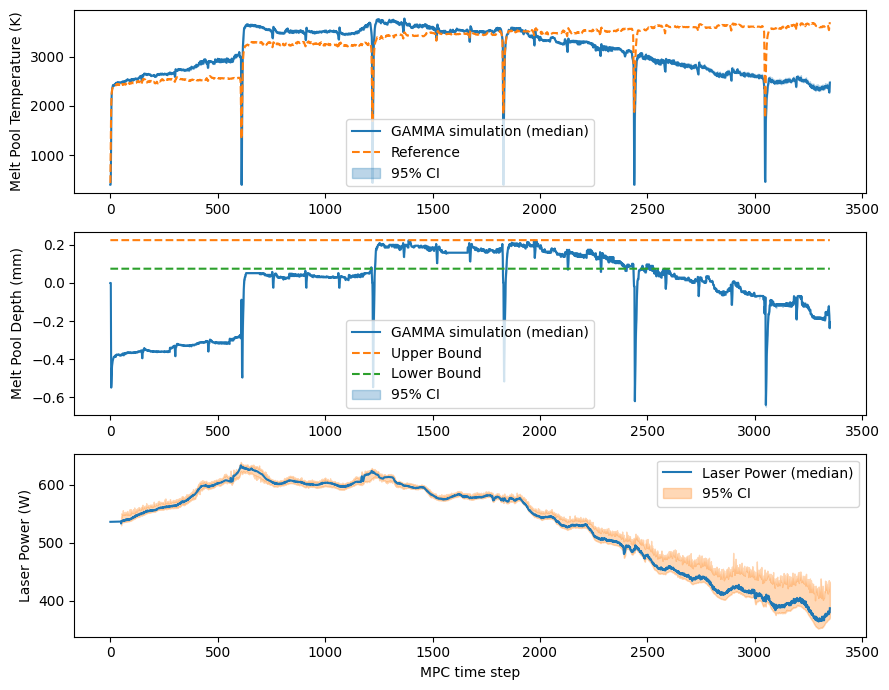

Laser 2:  54%|█████▍    | 3350/6195 [32:56<28:37,  1.66it/s]

[CI DEBUG @ step 3400] u_low=371.061768, u_mid=382.495972, u_high=428.158752, spread=5.709698e+01, std(norm)=1.435714e-01


Laser 2:  56%|█████▌    | 3450/6195 [33:56<28:23,  1.61it/s]

[CI DEBUG @ step 3500] u_low=387.402161, u_mid=394.371399, u_high=434.411804, spread=4.700964e+01, std(norm)=1.241509e-01


Laser 2:  57%|█████▋    | 3550/6195 [34:56<26:39,  1.65it/s]

[CI DEBUG @ step 3600] u_low=352.436249, u_mid=364.946045, u_high=417.395447, spread=6.495920e+01, std(norm)=1.689681e-01


Laser 2:  58%|█████▊    | 3600/6195 [35:26<25:55,  1.67it/s]

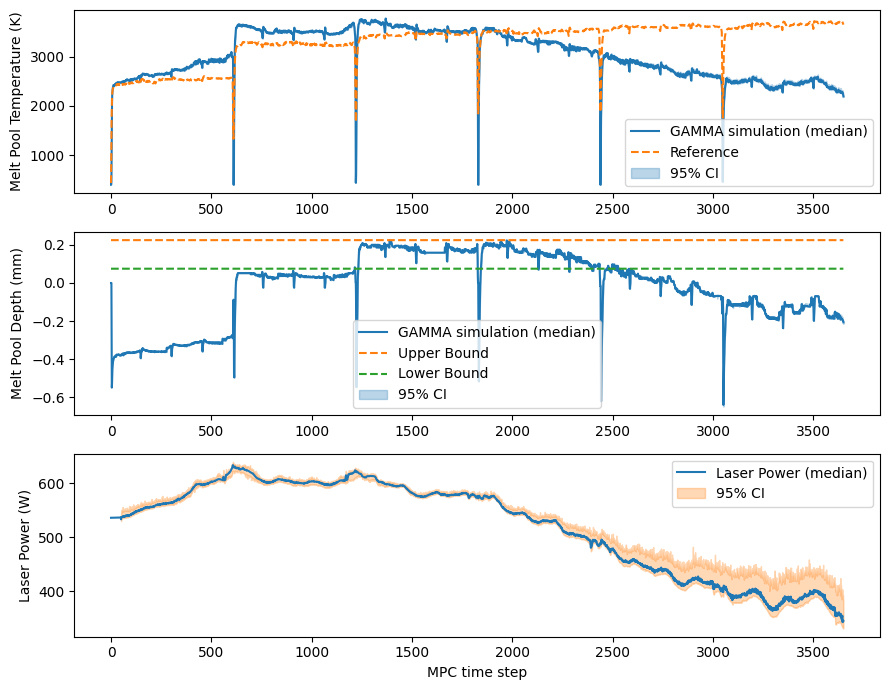

Laser 2:  59%|█████▉    | 3650/6195 [35:56<25:06,  1.69it/s]

[CI DEBUG @ step 3700] u_low=311.926636, u_mid=329.494141, u_high=380.310272, spread=6.838364e+01, std(norm)=1.796585e-01


Laser 2:  61%|██████    | 3750/6195 [36:56<24:43,  1.65it/s]

[CI DEBUG @ step 3800] u_low=325.103333, u_mid=344.132477, u_high=396.723022, spread=7.161969e+01, std(norm)=1.846066e-01


Laser 2:  62%|██████▏   | 3850/6195 [37:56<23:34,  1.66it/s]

[CI DEBUG @ step 3900] u_low=344.657867, u_mid=359.767151, u_high=397.679657, spread=5.302179e+01, std(norm)=1.294750e-01


Laser 2:  63%|██████▎   | 3874/6195 [38:11<22:52,  1.69it/s]


KeyboardInterrupt: 

In [7]:
device = torch.device("cuda:0")

# ── Constants ─────────────────────────────────────
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50
P = 50
MC_SAMPLES = 100   # ⭐ MC Dropout 샘플 수

model_path = "/home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/rollout_aug_v1_rollout10_epoch10_t1_s1_c1_sampling1024/checkpoints/policy_aug_1step_rollout0001.pth"

# ── Load model ─────────────────────────────────────
ckpt = torch.load(model_path, map_location=device)
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=P,
    window=window,
    hidden_dim=1024,
    n_layers=3,
    dropout_p=0.1
).to(device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# ⭐ Dropout만 활성화 (중요!)
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.train()

# ── Output directory ───────────────────────────────
save_dir = "/home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/rollout_aug_v1_rollout10_epoch10_t1_s1_c1_sampling1024/simulation/0001"
os.makedirs(save_dir, exist_ok=True)

# ── Loop over laser_power_number ───────────────────
for laser_num in range(2, 30):
    try:
        # ------------------------------------------------
        # Step 1: Load CSV
        # ------------------------------------------------
        csv_path = f"/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/split_by_laser_power_number/laser_power_number_{laser_num}.csv"
        df = pd.read_csv(csv_path)

        # ------------------------------------------------
        # Step 2: GAMMA init
        # ------------------------------------------------
        GAMMA_class = GAMMA_obj(
            INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR,
            CLOUD_TARGET_BASE_PATH, solidus_temp, window,
            init_runs, sim_interval, laser_power_number=laser_num
        )

        # ------------------------------------------------
        # Step 3: Initial steps
        # ------------------------------------------------
        init_avg = GAMMA_class.run_initial_steps()
        init_avg = torch.tensor(init_avg, dtype=torch.float32).to(device)[:, -window:]

        # ------------------------------------------------
        # Step 4: Inputs
        # ------------------------------------------------
        loc_Z  = df["Z"].to_numpy().reshape(-1, 1)
        dist_X = df["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
        dist_Y = df["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)

        fix_covariates = torch.tensor(
            np.concatenate((loc_Z, dist_X, dist_Y), axis=1),
            dtype=torch.float32
        ).to(device)

        laser_power_ref  = torch.tensor(df["Laser_power"].to_numpy().reshape(-1, 1), dtype=torch.float32).to(device)
        laser_power_past = laser_power_ref[:window]

        mp_temp_raw = df["melt_pool_temperature"].to_numpy()
        mp_temp = mp_temp_raw.copy()
        mp_temp[1:-2] = moving_average_1d(mp_temp_raw, 4)
        mp_temp_ref = torch.tensor(mp_temp, dtype=torch.float32).to(device)

        mp_depth_raw = df["melt_pool_depth"].to_numpy()
        mp_depth = mp_depth_raw.copy()
        mp_depth[1:-2] = moving_average_1d(mp_depth_raw, 4)
        mp_depth_ref = torch.tensor(mp_depth, dtype=torch.float32).to(device)

        # ------------------------------------------------
        # Step 5: GAMMA state init
        # ------------------------------------------------
        GAMMA_class.ref = mp_temp_ref.clone()
        GAMMA_class.fix_cov_all = fix_covariates.clone()
        GAMMA_class.x_past = init_avg.clone()
        GAMMA_class.u_past = laser_power_past.clone()

        GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone()
        GAMMA_class.u_past_save = GAMMA_class.u_past.clone()

        # ⭐ CI 저장 버퍼 초기화
        GAMMA_class.u_ci_save = torch.empty((0, 3), device=device)
        GAMMA_class.x_ci_save = torch.empty((0, 6), device=device)

        GAMMA_class.MPC_counter = window
        GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1]
        GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1)

        # ------------------------------------------------
        # Step 6: Simulation loop
        # ------------------------------------------------
        N_step = len(mp_temp_ref) - P

        for i in tqdm(range(N_step - P), desc=f"Laser {laser_num}"):
            out = run_one_step_policy(
                GAMMA_class,
                model,
                P=P,
                window=window,
                mc_samples=MC_SAMPLES
            )

            # ⭐ CI 저장
            GAMMA_class.u_ci_save = torch.cat(
                (GAMMA_class.u_ci_save,
                 torch.tensor([[out["u_low"], out["u_mid"], out["u_high"]]], device=device)),
                dim=0
            )

            GAMMA_class.x_ci_save = torch.cat(
                (GAMMA_class.x_ci_save,
                 torch.tensor([[out["x_low"], out["x_mid"], out["x_high"],
                                out["d_low"], out["d_mid"], out["d_high"]]], device=device)),
                dim=0
            )

            if i % 300 == 0:
                plot_fig(GAMMA_class, N_step)

        # ------------------------------------------------
        # Step 7: Save outputs
        # ------------------------------------------------
        pd.DataFrame(GAMMA_class.x_past_save.cpu().numpy()).to_csv(
            os.path.join(save_dir, f"x_outputs_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(GAMMA_class.u_past_save.cpu().numpy()).to_csv(
            os.path.join(save_dir, f"u_outputs_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(GAMMA_class.ref.cpu().numpy()).to_csv(
            os.path.join(save_dir, f"ref_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(GAMMA_class.u_ci_save.cpu().numpy(),
                     columns=["u_low", "u_mid", "u_high"]).to_csv(
            os.path.join(save_dir, f"u_ci_laser_{laser_num}.csv"), index=False)

        pd.DataFrame(GAMMA_class.x_ci_save.cpu().numpy(),
                     columns=[
                         "temp_low", "temp_mid", "temp_high",
                         "depth_low", "depth_mid", "depth_high"
                     ]).to_csv(
            os.path.join(save_dir, f"x_ci_laser_{laser_num}.csv"), index=False)

        print(f"✅ Completed and saved for laser_power_number {laser_num}")

    except Exception as e:
        print(f"❌ Error in laser_power_number {laser_num}: {e}")
